In [1]:
import scipy.linalg as la
from qiskit import QuantumCircuit, QuantumRegister, transpile
%matplotlib inline
import numpy as np
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from iqm.qiskit_iqm.fake_backends import fake_aphrodite
from qiskit.circuit.library import EfficientSU2
from qiskit_aer import AerSimulator

In [2]:
# Function for generating calibration circuits for the chosen number of qubits
def calibration_circuits(num_qubits):
    circuits = []
    for i in range(2**num_qubits):
        state = reversed(format(i, f'0{num_qubits}b'))
        qc = QuantumCircuit(num_qubits, num_qubits)
        
        for j, bit in enumerate(state):
            if bit == '1':
                qc.x(j)
        
        qc.measure(range(num_qubits), range(num_qubits))
        circuits.append(qc)
    
    return circuits

# Function for generating a mitigation matrix from the calibration results
def mitigation_matrix(calibration_results, num_qubits):
    num_states = 2**num_qubits
    M = np.zeros((num_states, num_states))
    
    for state_index in range(num_states):
        counts = calibration_results.get_counts(state_index)
        total_shots = sum(counts.values())
        
        for measured_state, count in counts.items():
            measured_state_index = int(measured_state, 2)
            M[measured_state_index, state_index] = count / total_shots
    
    return M

# Function that applies inverse of mitigation matrix to noisy counts to obtain mitigatated counts
def mitigate_counts(noisy_counts, Minv, num_qubits, shots):
    counts_vector = np.zeros(2**num_qubits)
    for state, count in noisy_counts.items():
        index = int(state, 2)
        counts_vector[index] = count
    
    mitigated_vector = np.dot(Minv, counts_vector)
    
    mitigated_vector = np.maximum(mitigated_vector, 0)
    mitigated_vector = mitigated_vector * shots / np.sum(mitigated_vector)
    
    mitigated_counts = {}
    for i in range(len(mitigated_vector)):
        state = format(i, f'0{num_qubits}b')
        mitigated_counts[state] = round(mitigated_vector[i])
    
    return mitigated_counts

In [3]:
# Choosing backend
backend = fake_aphrodite.IQMFakeAphrodite()

num_qubits = 4          # Number of qubits
layout = [10,11,18,19]  # Qubits for initial layout
shots = 10000           # Number of shots

# Generating and running calibration circuits
calibration_circuits_1 = calibration_circuits(num_qubits)
calibration_circuits = transpile(calibration_circuits_1, backend=backend, initial_layout=layout, optimization_level=3) 
calibration_job = backend.run(calibration_circuits, shots=shots)
calibration_results = calibration_job.result()
print("Calibration results:")
print(calibration_results.get_counts())
    
# Building mitigation matrix
M = mitigation_matrix(calibration_results, num_qubits)
print()
print("Calibration matrix M:")
print(M)
    
# Calculating inverse matrix
Minv = la.inv(M)
print()
print("Inverse matrix Minv:")
print(Minv)

Calibration results:
[{'0111': 1, '1011': 2, '0101': 30, '0001': 475, '0011': 28, '1001': 24, '1101': 4, '1010': 24, '1000': 502, '0100': 416, '1100': 26, '0110': 22, '0010': 451, '0000': 7995}, {'0110': 1, '1010': 3, '1111': 2, '1101': 21, '1000': 27, '1011': 25, '0010': 22, '0000': 411, '0111': 23, '0001': 8093, '0011': 454, '0101': 451, '1001': 444, '1100': 2, '0100': 21}, {'1001': 2, '1101': 1, '1111': 1, '0101': 1, '1011': 18, '1100': 2, '0100': 32, '0011': 463, '0001': 37, '0110': 376, '1010': 487, '0111': 24, '1110': 36, '1000': 30, '0000': 442, '0010': 8048}, {'1110': 2, '0101': 21, '1001': 33, '1010': 29, '0110': 24, '0011': 8079, '0001': 452, '1011': 473, '1101': 1, '1111': 21, '0111': 422, '0000': 31, '0010': 412}, {'1001': 1, '0011': 5, '0001': 23, '1111': 1, '1101': 26, '0010': 23, '0000': 406, '1110': 31, '1000': 32, '0100': 7999, '1100': 501, '0111': 32, '0101': 498, '0110': 422}, {'1010': 1, '1110': 2, '0010': 5, '1000': 4, '1011': 4, '0100': 364, '1100': 29, '1001': 26

Noiseless counts {'0100': 1, '0001': 1, '0000': 9998}
Noisy counts: {'1001': 53, '0111': 57, '1111': 81, '1101': 51, '0101': 222, '1011': 37, '1010': 186, '0110': 257, '0011': 188, '0001': 384, '1100': 351, '0100': 547, '0000': 6253, '0010': 444, '1110': 189, '1000': 700}
Mitigated counts: {'0000': 7771, '0001': 0, '0010': 80, '0011': 196, '0100': 230, '0101': 225, '0110': 264, '0111': 25, '1000': 353, '1001': 15, '1010': 171, '1011': 16, '1100': 369, '1101': 17, '1110': 185, '1111': 83}


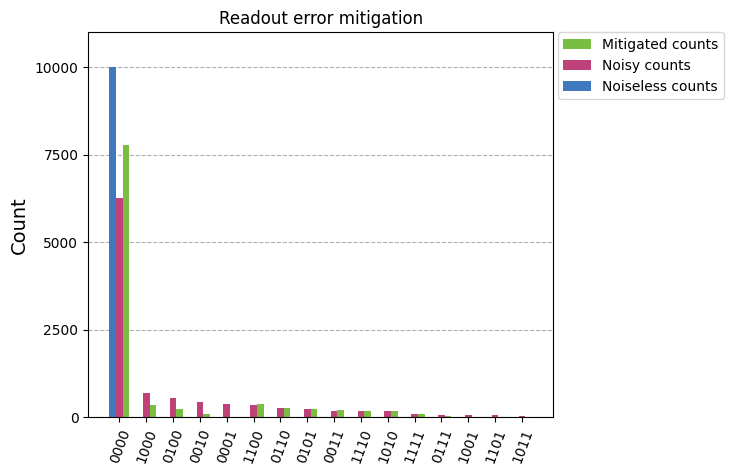

In [4]:
# Defining circuit to be run
qc = EfficientSU2(num_qubits=num_qubits, entanglement="linear")
x0 = np.random.normal(0, 0.01, qc.num_parameters) 
qc = qc.assign_parameters(x0)
qc.measure_all()
    
# Getting noisy results
noisy_result_1 = transpile(qc, backend=backend, initial_layout=layout, optimization_level=3)
noisy_result = backend.run(noisy_result_1, shots=shots).result()
noisy_counts = noisy_result.get_counts()
    
# Getting mitigated results
mitigated_counts = mitigate_counts(noisy_counts, Minv, num_qubits, shots)
noiseless_counts = AerSimulator().run(qc.decompose(), shots=10000).result().get_counts()

# Printing counts
print("Noiseless counts", noiseless_counts)
print("Noisy counts:", noisy_counts)
print("Mitigated counts:", mitigated_counts)
    
# Plotting results
legend = ['Mitigated counts', 'Noisy counts', 'Noiseless counts']
fig = plot_histogram([mitigated_counts, noisy_counts, noiseless_counts], legend=legend, color=['#79BE41','#BE4179','#4179BE'], title="Readout error mitigation", sort="value_desc", bar_labels=False, figsize=[6,5])
fig.savefig("Readout_error_mitigation")

Noiseless counts {'0011': 5044, '0000': 4956}
Noisy counts: {'1110': 2, '1001': 28, '1111': 16, '1101': 2, '1010': 25, '0100': 225, '1100': 14, '1000': 213, '1011': 208, '0101': 33, '0001': 520, '0011': 4008, '0111': 203, '0110': 25, '0010': 505, '0000': 3973}
Mitigated counts: {'0000': 4897, '0001': 76, '0010': 97, '0011': 4891, '0100': 23, '0101': 4, '0110': 0, '0111': 0, '1000': 0, '1001': 0, '1010': 0, '1011': 0, '1100': 2, '1101': 0, '1110': 1, '1111': 9}


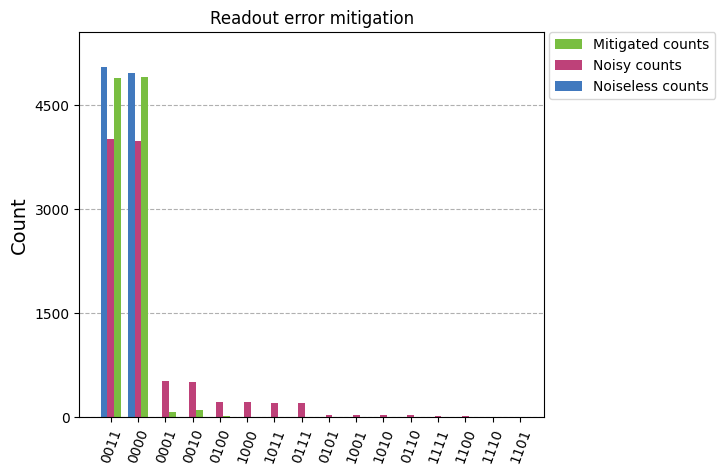

In [5]:
# Defining circuit to be run
qc = QuantumCircuit(4,4)
qc.h(0)
qc.cx(0,1)  
qc.measure(qc.qregs[0],qc.cregs[0])

# Getting noisy results
noisy_result_1 = transpile(qc, backend=backend, optimization_level=3)
noisy_result = backend.run(noisy_result_1, shots=shots).result()
noisy_counts = noisy_result.get_counts()
    
# Getting mitigated results
mitigated_counts = mitigate_counts(noisy_counts, Minv, num_qubits, shots)
noiseless_counts = AerSimulator().run(qc.decompose(), shots=10000).result().get_counts()

# Printing counts
print("Noiseless counts", noiseless_counts)
print("Noisy counts:", noisy_counts)
print("Mitigated counts:", mitigated_counts)
    
# Plotting results
legend = ['Mitigated counts', 'Noisy counts', 'Noiseless counts']
fig = plot_histogram([mitigated_counts, noisy_counts, noiseless_counts], legend=legend, color=['#79BE41','#BE4179','#4179BE'], title="Readout error mitigation", sort="value_desc", bar_labels=False, figsize=[6,5])
fig.savefig("Readout_error_mitigation")

Noiseless counts {'0000': 4957, '1111': 5043}
Noisy counts: {'0110': 35, '1000': 247, '1001': 34, '1010': 42, '0101': 30, '1111': 3810, '1101': 266, '1110': 272, '0100': 171, '1100': 95, '1011': 236, '0011': 115, '0001': 307, '0111': 258, '0010': 253, '0000': 3829}
Mitigated counts: {'0000': 4760, '0001': 92, '0010': 37, '0011': 97, '0100': 0, '0101': 0, '0110': 9, '0111': 21, '1000': 2, '1001': 5, '1010': 20, '1011': 37, '1100': 81, '1101': 56, '1110': 66, '1111': 4717}


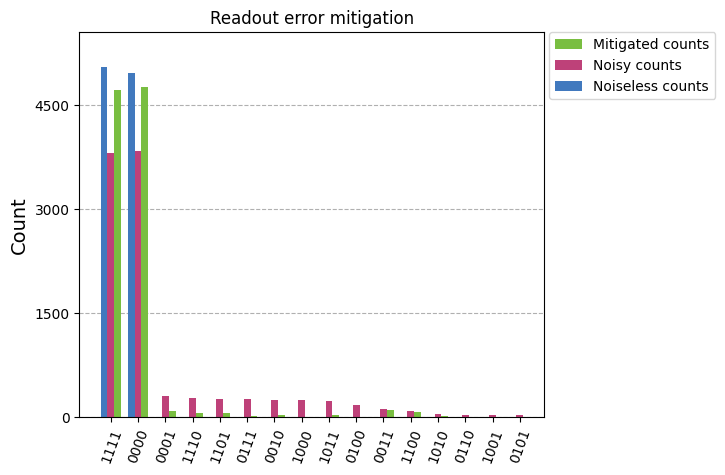

In [6]:
# Defining circuit to be run
qc = QuantumCircuit(num_qubits)
qc.sx(0)
for i in range(1, num_qubits):
    qc.cx(i - 1, i)
qc.measure_all()

# Getting noisy results
noisy_result_1 = transpile(qc, backend=backend, optimization_level=3)
noisy_result = backend.run(noisy_result_1, shots=shots).result()
noisy_counts = noisy_result.get_counts()
    
# Getting mitigated results
mitigated_counts = mitigate_counts(noisy_counts, Minv, num_qubits, shots)

# Getting noiseless counts
noiseless_counts = AerSimulator().run(qc.decompose(), shots=10000).result().get_counts()

# Printing counts
print("Noiseless counts", noiseless_counts)
print("Noisy counts:", noisy_counts)
print("Mitigated counts:", mitigated_counts)
    
# Plotting results
legend = ['Mitigated counts', 'Noisy counts', 'Noiseless counts']
fig = plot_histogram([mitigated_counts, noisy_counts, noiseless_counts], legend=legend, color=['#79BE41','#BE4179','#4179BE'], title="Readout error mitigation", sort="value_desc", bar_labels=False, figsize=[6,5])
fig.savefig("Readout_error_mitigation")